In [1]:
# -*- coding: utf-8 -*-
# Face Recognition using MTCNN + FaceNet + SVM
# সম্পূর্ণ প্রজেক্ট function base

# ----------------------------
# Step 0: Libraries Install & Import
# ----------------------------

import os
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from mtcnn.mtcnn import MTCNN
from keras_facenet import FaceNet
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import pickle
import tensorflow as tf
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

# ----------------------------
# Step 1: Face Loader Class
# ----------------------------
class FACELOADING:
    def __init__(self, directory, target_size=(160,160)):
        self.directory = directory
        self.target_size = target_size
        self.X = []
        self.Y = []
        self.detector = MTCNN()
    
    # একটিমাত্র ইমেজ থেকে মুখ বের করা
    def extract_face(self, filename):
        img = cv.imread(filename)
        img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
        x, y, w, h = self.detector.detect_faces(img)[0]['box']
        x, y = abs(x), abs(y)
        face = img[y:y+h, x:x+w]
        face_arr = cv.resize(face, self.target_size)
        return face_arr
    
    # একটি ক্লাসের সব ছবি লোড করা
    def load_faces(self, dir):
        FACES = []
        for im_name in os.listdir(dir):
            try:
                path = os.path.join(dir, im_name)
                single_face = self.extract_face(path)
                FACES.append(single_face)
            except:
                pass
        return FACES

    # সব ক্লাসের ছবি লোড করা
    def load_classes(self):
        for sub_dir in os.listdir(self.directory):
            path = os.path.join(self.directory, sub_dir)
            FACES = self.load_faces(path)
            labels = [sub_dir for _ in range(len(FACES))]
            print(f"Loaded {len(labels)} images for class '{sub_dir}'")
            self.X.extend(FACES)
            self.Y.extend(labels)
        return np.asarray(self.X), np.asarray(self.Y)
    
    # লোড করা ছবিগুলো plot করা
    def plot_images(self):
        plt.figure(figsize=(18,16))
        for num, image in enumerate(self.X):
            ncols = 3
            nrows = len(self.Y)//ncols + 1
            plt.subplot(nrows, ncols, num+1)
            plt.imshow(image)
            plt.axis('off')
        plt.show()

# ----------------------------
# Step 2: Embedding Function
# ----------------------------
embedder = FaceNet()

def get_embedding(face_img):
    face_img = face_img.astype('float32')
    face_img = np.expand_dims(face_img, axis=0)  # (1,160,160,3)
    yhat = embedder.embeddings(face_img)
    return yhat[0]  # 512D embedding

# ----------------------------
# Step 3: Train SVM Function
# ----------------------------
def train_svm(X, Y):
    encoder = LabelEncoder()
    Y_enc = encoder.fit_transform(Y)
    X_train, X_test, Y_train, Y_test = train_test_split(X, Y_enc, shuffle=True, random_state=17)
    
    model = SVC(kernel='linear', probability=True)
    model.fit(X_train, Y_train)
    
    train_acc = accuracy_score(Y_train, model.predict(X_train))
    test_acc = accuracy_score(Y_test, model.predict(X_test))
    print(f"Train Accuracy: {train_acc}")
    print(f"Test Accuracy: {test_acc}")
    
    return model, encoder

# ----------------------------
# Step 4: Predict Single Image
# ----------------------------
def predict_image(model, encoder, image_path):
    detector = MTCNN()
    img = cv.imread(image_path)
    img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
    x, y, w, h = detector.detect_faces(img)[0]['box']
    img = img[y:y+h, x:x+w]
    img = cv.resize(img, (160,160))
    embedding = get_embedding(img).reshape(1,-1)
    ypred = model.predict(embedding)
    pred_name = encoder.inverse_transform(ypred)
    print(f"Predicted Person: {pred_name[0]}")
    return pred_name[0]

# ----------------------------
# Step 5: Save SVM Model
# ----------------------------
def save_model(model, filename='svm_model.pkl'):
    with open(filename, 'wb') as f:
        pickle.dump(model, f)
    print(f"Model saved to {filename}")

# ----------------------------
# Step 6: Complete Pipeline
# ----------------------------
def run_pipeline(train_dir, test_image_path):
    # Load Dataset
    fl = FACELOADING(train_dir)
    X, Y = fl.load_classes()
    
    # Plot some sample images
    fl.plot_images()
    
    # Embedding
    EMBEDDED_X = np.array([get_embedding(img) for img in X])
    
    # Train SVM
    model, encoder = train_svm(EMBEDDED_X, Y)
    
    # Predict test image
    predict_image(model, encoder, test_image_path)
    
    # Save model
    save_model(model)

2025-11-04 08:49:52.416095: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-04 08:49:52.416388: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-04 08:49:52.453963: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-04 08:49:54.455481: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


Loaded 5 images for class 'trent'
Loaded 4 images for class 'costa'
Loaded 5 images for class 'fernandes'
Loaded 6 images for class 'dias'
Loaded 5 images for class 'kohli'
Loaded 6 images for class 'cancelo'
Loaded 6 images for class 'pickford'
Loaded 3 images for class 'sinner'
Loaded 5 images for class 'brozovic'
Loaded 5 images for class 'vitinha'
Loaded 5 images for class 'deligt'


2025-11-04 08:53:49.114855: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: INVALID_ARGUMENT: Incompatible shapes: [0,48,48,3] vs. [1,1,1,32]


Loaded 5 images for class 'messi'
Loaded 5 images for class 'bale'
Loaded 5 images for class 'pepe'
Loaded 4 images for class 'saka'
Loaded 5 images for class 'marcelo'
Loaded 7 images for class 'ozil'
Loaded 5 images for class 'bruyne'
Loaded 5 images for class 'casimiro'
Loaded 6 images for class 'mbappe'
Loaded 6 images for class 'ramos'
Loaded 5 images for class 'rodriguez'
Loaded 3 images for class 'shelton'
Loaded 6 images for class 'ronaldo'
Loaded 5 images for class 'mendes'
Loaded 4 images for class 'mane'
Loaded 5 images for class 'haaland'
Loaded 5 images for class 'gordon'
Loaded 2 images for class 'cummins'
Loaded 5 images for class 'aqidi'


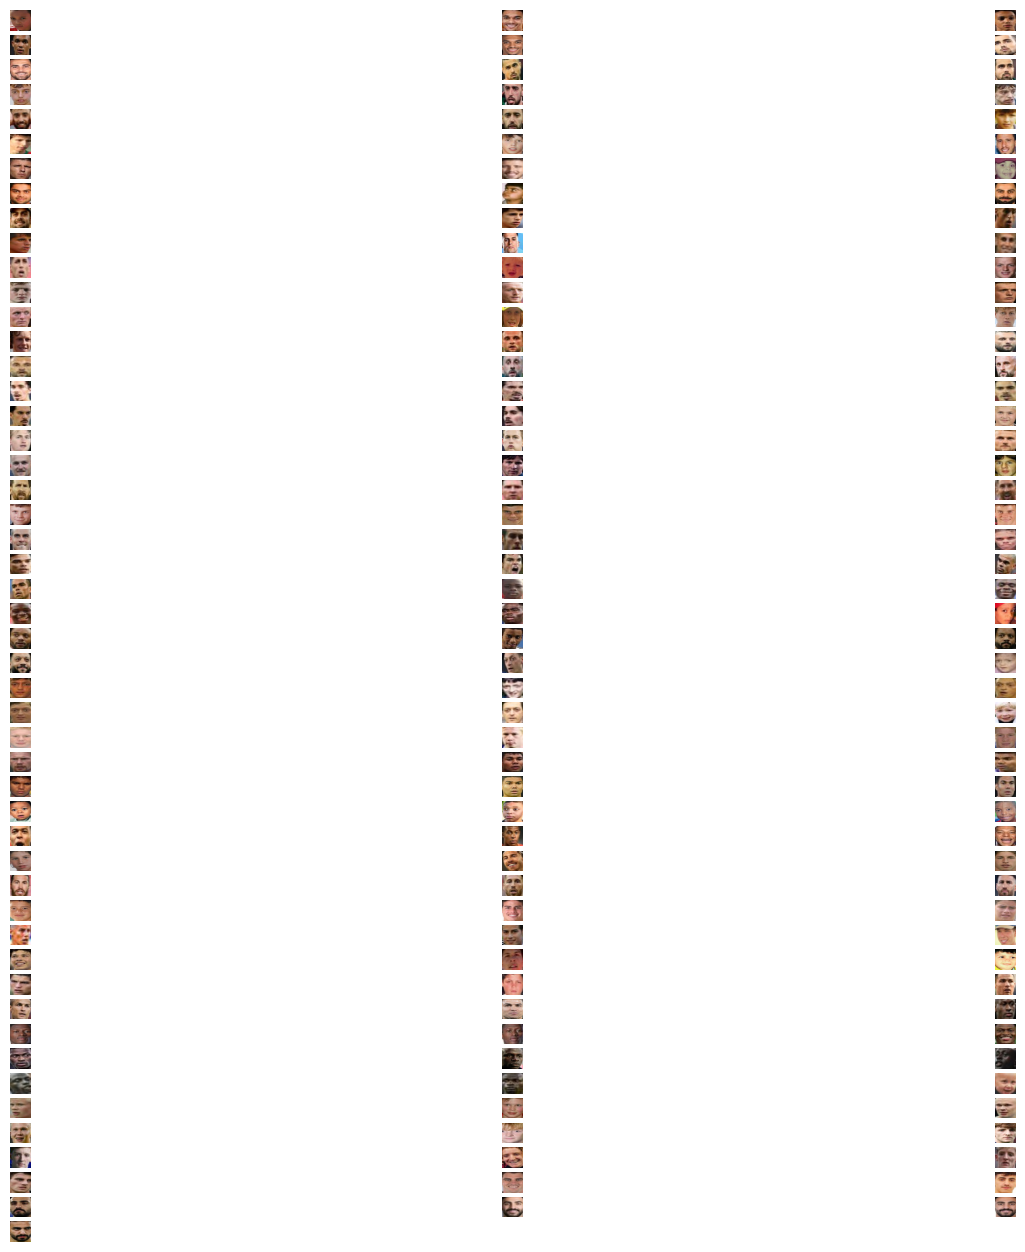

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━

/home/shagor/Desktop/code/deep learning/env_dl/lib/python3.12/site-packages/sklearn/metrics/_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
/home/shagor/Desktop/code/deep learning/env_dl/lib/python3.12/site-packages/sklearn/metrics/_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Predicted Person: ronaldo
Model saved to svm_model.pkl


In [3]:
# ----------------------------
# Step 7: Run the Pipeline
# ----------------------------
train_dataset_path = '../dataset/train/'
test_image_path = '../dataset/test/ronaldo/ronaldo.jpg'

run_pipeline(train_dataset_path, test_image_path)